In [14]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install "numpy<2"

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [21 lines of output]
  + C:\Users\isscpu\AppData\Local\anaconda3\python.exe C:\Users\isscpu\AppData\Local\Temp\pip-install-uw23pzth\numpy_484b101967494ce58cfc5d29fce14157\vendored-meson\meson\meson.py setup C:\Users\isscpu\AppData\Local\Temp\pip-install-uw23pzth\numpy_484b101967494ce58cfc5d29fce14157 C:\Users\isscpu\AppData\Local\Temp\pip-install-uw23pzth\numpy_484b101967494ce58cfc5d29fce14157\.mesonpy-6ctffejm -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\isscpu\AppData\Local\Temp\pip-install-uw23pzth\numpy_484b101967494ce58cfc5d29fce14157\.mesonpy-6ctffejm\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\isscpu\AppData\Local\Temp\pip-install-uw23pzth\numpy_484b101967494ce58cfc5d29fce14157
  Build dir: C:\Users\isscpu\AppData\Local\Temp\pip-install-uw23pzth\numpy_484b101967494ce58cfc5d

In [15]:
import pmdarima as pm

In [16]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt
from sklearn.metrics import mean_absolute_percentage_error

In [17]:
import warnings
warnings.filterwarnings("ignore")

**Hotel Occupancy**

In [18]:
#load the data
df = pd.read_csv("https://raw.githubusercontent.com/christinecheongpuayee88/christinecheong/master/public/notebooks/data/hotelocc.csv",
                 index_col = 'Time',
                 parse_dates = True)
df.head()

,Y
Time,
1,4.73
2,4.70
3,4.74
4,4.90
5,4.83


<Axes: xlabel='Time'>

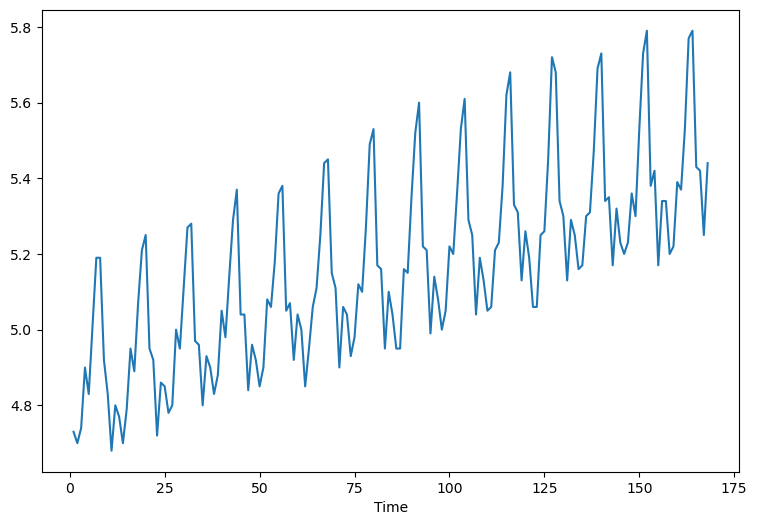

In [19]:
#Y Viz
df.Y.plot(figsize = (9,6))

In [20]:
#Stationarity
from statsmodels.tsa.stattools import adfuller
stationarity = adfuller(df['Y'])
print('Augmented Dickey Fuller p-value: %F' % stationarity[1])

Augmented Dickey Fuller p-value: 0.281799


In [21]:
#Training and test set
test = 10
training_set = df.iloc[:-test, :]
test_set = df.iloc[-test:, :]
test_set

,Y
Time,
159,5.22
160,5.39
161,5.37
162,5.53
163,5.77
164,5.79
165,5.43
166,5.42
167,5.25


In [22]:
training_set

,Y
Time,
1,4.73
2,4.70
3,4.74
4,4.90
5,4.83
...,...
154,5.42
155,5.17
156,5.34


**ARIMA & SARIMA (using Auto Arima)**

In [38]:
#ARIMA - take a while to generate results
from pmdarima import auto_arima
model1 = auto_arima(y = training_set.Y,
                    test='adf', seasonal=True,
                    max_p=3, max_q=3, m=12,
                   stepwise = True)
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  110
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 169.247
Date:                            Sun, 19 Jul 2026   AIC                           -332.494
Time:                                    19:30:58   BIC                           -324.770
Sample:                                         0   HQIC                          -329.371
                                            - 110                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4235      0.093     -4.532      0.000      -0.607      -0.240
ma.S.L12      -0.6087      0.096     -6.316      0.000      -0.798      -0.420
sigma2         0.0017      0.000      8.283      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 5.84
Prob(Q):                              0.72   Prob(JB):                         0.05
Heteroskedasticity (H):               0.33   Skew:                             0.37
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
#Predictions (model1)
predictions = pd.Series(model1.predict(n_periods= test)).rename("ARIMA")
predictions.index = test_set.index
predictions.head()

Time
159    5.254457
160    5.379201
161    5.380630
162    5.568519
163    5.783905
Name: ARIMA, dtype: float64

In [26]:
mape = mean_absolute_percentage_error(test_set.Y, predictions) * 100
print(f"MAPE for model: {mape:.2f}%")

MAPE for model: 0.44%


In [34]:
# ARIMA and SARIMA (Manual Model Specification). Import the correct ARIMA class
from statsmodels.tsa.arima.model import ARIMA

In [37]:
# ARIMA
model = ARIMA(training_set.Y, order = (10,0,0))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      Y   No. Observations:                  110
Model:                ARIMA(10, 0, 0)   Log Likelihood                 115.382
Date:                Sun, 19 Jul 2026   AIC                           -206.764
Time:                        16:59:30   BIC                           -174.358
Sample:                             0   HQIC                          -193.620
                                - 110                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3500      0.568      9.414      0.000       4.236       6.464
ar.L1          1.0684      0.124      8.614      0.000       0.825       1.312
ar.L2         -0.2951      0.179     -1.647      0.099      -0.646       0.056
ar.L3          0.1539      0.188      0.818      0.413      -0.215       0.522
ar.L4         -0.3826      0.160     -2.397      0.017      -0.695      -0.070
ar.L5          0.3983      0.182      2.185      0.029       0.041       0.756
ar.L6         -0.0278      0.178     -0.156      0.876      -0.376       0.321
ar.L7         -0.0799      0.156     -0.511      0.610      -0.386       0.227
ar.L8         -0.2589      0.185     -1.399      0.162      -0.622       0.104
ar.L9          0.3324      0.191      1.741      0.082      -0.042       0.707
ar.L10         0.0857      0.115      0.745      0.456      -0.140       0.311
sigma2         0.0068      0.001      5.512      0.000       0.004       0.009
===================================================================================
Ljung-Box (L1) (Q):                   2.19   Jarque-Bera (JB):                 5.35
Prob(Q):                              0.14   Prob(JB):                         0.07
Heteroskedasticity (H):               0.88   Skew:                             0.39
Prob(H) (two-sided):                  0.71   Kurtosis:                         2.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Airline**

In [27]:
#load the data
df = pd.read_csv("https://raw.githubusercontent.com/christinecheongpuayee88/christinecheong/master/public/notebooks/data/Airline.csv",
                 index_col = 'Time',
                 parse_dates = True)
df.head()

,Y
Time,
1,4.72
2,4.77
3,4.88
4,4.86
5,4.80


<Axes: xlabel='Time'>

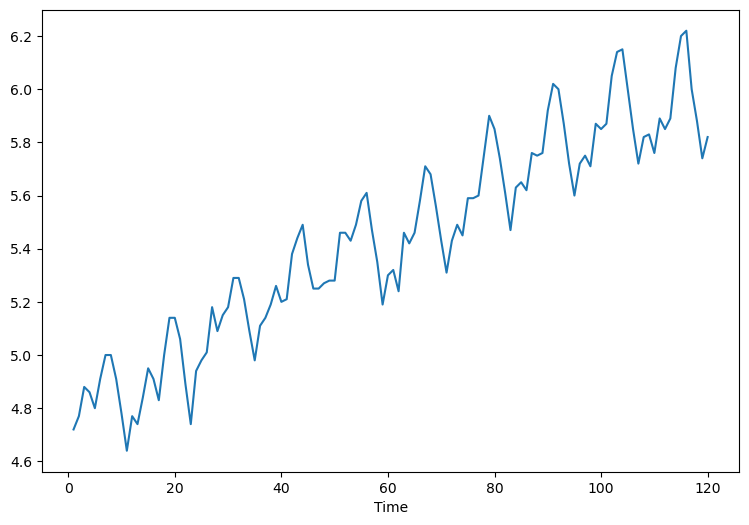

In [28]:
#Y Viz
df.Y.plot(figsize = (9,6))

In [30]:
#Stationarity
from statsmodels.tsa.stattools import adfuller
stationarity = adfuller(df['Y'])
print('Augmented Dickey Fuller p-value: %F' % stationarity[1])

Augmented Dickey Fuller p-value: 0.342234


In [31]:
#Training and test set
test = 10
training_set = df.iloc[:-test, :]
test_set = df.iloc[-test:, :]
test_set

,Y
Time,
111,5.89
112,5.85
113,5.89
114,6.08
115,6.20
116,6.22
117,6.00
118,5.88
119,5.74


In [32]:
training_set

,Y
Time,
1,4.72
2,4.77
3,4.88
4,4.86
5,4.80
...,...
106,5.85
107,5.72
108,5.82


In [33]:
#ARIMA - take a while to generate results
from pmdarima import auto_arima
model1 = auto_arima(y = training_set.Y,
                    test='adf', seasonal=True,
                    max_p=3, max_q=3, m=12,
                   stepwise = True)
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  110
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 169.247
Date:                            Sun, 19 Jul 2026   AIC                           -332.494
Time:                                    16:53:52   BIC                           -324.770
Sample:                                         0   HQIC                          -329.371
                                            - 110                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4235      0.093     -4.532      0.000      -0.607      -0.240
ma.S.L12      -0.6087      0.096     -6.316      0.000      -0.798      -0.420
sigma2         0.0017      0.000      8.283      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 5.84
Prob(Q):                              0.72   Prob(JB):                         0.05
Heteroskedasticity (H):               0.33   Skew:                             0.37
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""